## Test loopback notebook

Demonstrates how to generate an arbitrary pulse shape, save it to an `.npy` file, and play and capture it in loopback mode.

In [3]:
# %matplotlib widget
%load_ext autoreload
%autoreload 2
from pathlib import Path
import matplotlib.pyplot as plt
plt.style.use('default')
import numpy as np
from system_info import BOARD_IP, YAML_PATH, DATA_DIR
from acadia_qmsmt.utils.yaml_editor import update_yaml, load_yaml


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### generate and save a test pulse

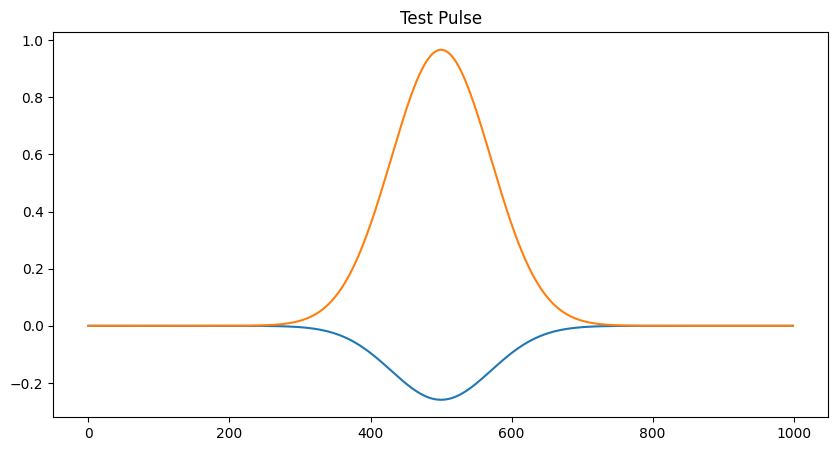

In [6]:
sampling_points = np.arange(0, 1000, 1) # 1.25 ns per sampling point
test_pulse = np.exp(-(sampling_points-500)**2/100**2) + 1j*np.exp(-(sampling_points-500)**2/100**2) # generate test pulse shape
test_pulse/= np.max(np.abs(test_pulse))*np.exp(-1j*np.pi/3)  # normalize pulse


# plot pulse
plt.figure(figsize=(10, 5))
plt.plot(sampling_points, np.real(test_pulse), label='Real Part')
plt.plot(sampling_points, np.imag(test_pulse), label='Imaginary Part')
plt.title('Test Pulse')

# save data and update YAML
save_pulse_path = f"./arb_pulses/test_pulse.npy"
Path(save_pulse_path).parent.mkdir(parents=True, exist_ok=True)
np.save(save_pulse_path, test_pulse)
_ = update_yaml(YAML_PATH, {"ro_stimulus.pulses.test_pulse.data":str(Path(save_pulse_path).absolute())}, verbose=False)


# test loopback

In [ ]:
from acadia_qmsmt.runtimes.loopback_amp_sweep import LoopbackAmpSweepRuntime
iterations = 20000

oct_pulse_name = "test_pulse"
amp_list = 0.6*np.exp(-1j*np.pi/2) # if None, will use the amplitude in yaml file 
nco_frequency = 8.8e9  # Hz. If None, will use the frequency in yaml file 
capture_delay = 200e-9

rt = LoopbackAmpSweepRuntime(stimulus="ro_stimulus", capture="ro_capture",
                              stimulus_pulse_name=oct_pulse_name,
                              capture_delay=capture_delay,
                              amp_list=amp_list, nco_frequency=nco_frequency,
                           iterations=iterations, yaml_path=YAML_PATH)
rt.deploy(BOARD_IP, local_directory=DATA_DIR + "testLoopback/%y%m%d_%H%M%S")
rt.display()